# Sprint 13 - Proyecto

### Libraries loading (Cargar las librerías)

In [1]:
# Data manipulation
from pathlib import Path
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Metrics
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    auc,
    f1_score,
    mean_squared_error
)

# Utilities
from sklearn.utils import shuffle


### Data loading (cargar los datos)

In [2]:
#Crea un objeto Path que representa el directorio actual, .resolve() convierte esa ruta en una ruta absoluta completa
BASE_DIR = Path().resolve()
DATA_DIR = BASE_DIR / "data" 

#Define las rutas de los archivos
train_path = DATA_DIR / "gold_recovery_train.csv"
test_path = DATA_DIR / "gold_recovery_test.csv"
full_path = DATA_DIR / "gold_recovery_full.csv" 

# Cargar datasets
gold_recovery_train = pd.read_csv(train_path)
gold_recovery_test = pd.read_csv(test_path)
gold_recovery_full = pd.read_csv(full_path)


### Exploratory Data Analysis (Análisis exploratorio de datos)

In [3]:
datasets = {
    "Train": gold_recovery_train,
    "Test": gold_recovery_test,
    "Full": gold_recovery_full
}

#Cálculo de dimensiones de los datasets
print("Dimensiones de los datasets:\n")

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

print("\nValores ausentes:\n")

#Cálculo de valores ausentes en cada dataset
for name, df in datasets.items():
    total_missing = df.isnull().sum().sum()
    total_values = df.size
    missing_percent = (total_missing / total_values) * 100
    
    print(f"{name} - Total valores ausentes: {total_missing} ({missing_percent:.2f}%)")
    
#Cálculo de valores ausentes por cada columna de cada dataset
for name, df in datasets.items():
    print(f"\nAnálisis de valores ausentes - {name}")
    
    missing_df = pd.DataFrame({
        "missing_count": df.isnull().sum(),
        "missing_percent": (df.isnull().mean() * 100).round(2)
    }).sort_values(by="missing_percent", ascending=False)
    
    print(missing_df.head(10))


Dimensiones de los datasets:

Train: (16860, 87)
Test: (5856, 53)
Full: (22716, 87)

Valores ausentes:

Train - Total valores ausentes: 30320 (2.07%)
Test - Total valores ausentes: 2360 (0.76%)
Full - Total valores ausentes: 36587 (1.85%)

Análisis de valores ausentes - Train
                                    missing_count  missing_percent
rougher.output.recovery                      2573            15.26
rougher.output.tail_ag                       2250            13.35
rougher.output.tail_au                       2249            13.34
rougher.output.tail_sol                      2249            13.34
secondary_cleaner.output.tail_sol            1986            11.78
rougher.input.floatbank11_xanthate           1904            11.29
final.output.recovery                        1521             9.02
primary_cleaner.input.sulfate                1307             7.75
primary_cleaner.input.depressant             1262             7.49
rougher.calculation.au_pb_ratio              1242    

In [4]:
# Identificar las columnas necesarias, aquellas relacionadas conrougher

rougher_cols = [col for col in gold_recovery_train.columns if 'rougher' in col]
print('Columnas rougher disponibles:')
for col in rougher_cols:
    print(f" - {col}")

Columnas rougher disponibles:
 - rougher.calculation.sulfate_to_au_concentrate
 - rougher.calculation.floatbank10_sulfate_to_au_feed
 - rougher.calculation.floatbank11_sulfate_to_au_feed
 - rougher.calculation.au_pb_ratio
 - rougher.input.feed_ag
 - rougher.input.feed_pb
 - rougher.input.feed_rate
 - rougher.input.feed_size
 - rougher.input.feed_sol
 - rougher.input.feed_au
 - rougher.input.floatbank10_sulfate
 - rougher.input.floatbank10_xanthate
 - rougher.input.floatbank11_sulfate
 - rougher.input.floatbank11_xanthate
 - rougher.output.concentrate_ag
 - rougher.output.concentrate_pb
 - rougher.output.concentrate_sol
 - rougher.output.concentrate_au
 - rougher.output.recovery
 - rougher.output.tail_ag
 - rougher.output.tail_pb
 - rougher.output.tail_sol
 - rougher.output.tail_au
 - rougher.state.floatbank10_a_air
 - rougher.state.floatbank10_a_level
 - rougher.state.floatbank10_b_air
 - rougher.state.floatbank10_b_level
 - rougher.state.floatbank10_c_air
 - rougher.state.floatbank10_

### Data Preprocessing (Preprocesamiento de datos)

In [5]:
# Realizar el cálculo de la característica rougher.output.recovery de forma manual

#C: concentración de la sustancia en el concentrado
C = gold_recovery_train['rougher.output.concentrate_au']

#F: concentración de la sustancia en la alimentación(feed)
F = gold_recovery_train['rougher.input.feed_au']

#T: concentración de la sustancia en las colas (tails)
T = gold_recovery_train['rougher.output.tail_au']

#Calcular la recuperación
recovery_calculated = (C * (F - T)/(F * (C - T))) * 100
print(f"Recovery calculada: {recovery_calculated.head().values}")

Recovery calculada: [87.10776293 86.84326051 86.84230826 87.22642953 86.68879414]


In [6]:
# Comparar los valores calculados y los valores originales

tolerance = 0.01

close_match = abs(recovery_calculated - gold_recovery_train['rougher.output.recovery']) < tolerance
print(f'Valores similares (±{tolerance}): {close_match.sum()} de {len(close_match)}')

# Calcular el MAE
mae = abs(recovery_calculated - gold_recovery_train['rougher.output.recovery']).mean()
print(f"Error Absoluto Medio: {mae}")

Valores similares (±0.01): 14287 de 16860
Error Absoluto Medio: 9.303415616264301e-15


De acuerdo con los datos calculados, se observa que 14287 datos de 16860 (aproximadamente el 84.7%) se encuentran dentro de un intervalo del ±10%, dejando algunos datos fuera por posibles causas como la forma en que se tomaron los datos, la precisión del análisis, la precisión de los instrumentos, incertidumbre de los instrumentos, error al tomar las medidas, etc.

Por otro lado, se observa que el Error Absoluto Medio es un valor muy pequeño, lo cual aporta información sobre que los datos calculados y los datos originales se encuentran muy cercanos entre ellos. 

##### 1.3. Analiza las características no disponibles en el conjunto de prueba. ¿Cuáles son estos parámetros? ¿Cuál es su tipo?

In [7]:
# Revisar qué columnas faltan en test vs train
train_cols = set(gold_recovery_train.columns)
test_cols = set(gold_recovery_test.columns)
missing_in_test = train_cols - test_cols

print(f"Columnas que están en train pero NO en test: {len(missing_in_test)}")
print("Columnas faltantes:")
print(list(missing_in_test)[:])

Columnas que están en train pero NO en test: 34
Columnas faltantes:
['final.output.tail_ag', 'secondary_cleaner.output.tail_sol', 'final.output.concentrate_sol', 'secondary_cleaner.output.tail_ag', 'rougher.output.tail_au', 'primary_cleaner.output.tail_ag', 'primary_cleaner.output.tail_au', 'rougher.output.tail_sol', 'primary_cleaner.output.concentrate_sol', 'primary_cleaner.output.concentrate_au', 'secondary_cleaner.output.tail_pb', 'rougher.output.concentrate_au', 'rougher.output.concentrate_pb', 'rougher.output.concentrate_sol', 'final.output.concentrate_ag', 'rougher.output.tail_ag', 'primary_cleaner.output.tail_sol', 'final.output.concentrate_pb', 'secondary_cleaner.output.tail_au', 'primary_cleaner.output.concentrate_ag', 'rougher.calculation.sulfate_to_au_concentrate', 'rougher.calculation.floatbank11_sulfate_to_au_feed', 'rougher.calculation.au_pb_ratio', 'final.output.tail_pb', 'rougher.output.concentrate_ag', 'rougher.output.tail_pb', 'final.output.recovery', 'final.output.co

Se observa que las columnas faltantes en el dataset de prueba (test) probablemente sean las variables objetivo, lo cual explicaría el porqué se encuentran en el dataset de entrenamiento pero no en el de prueba.

##### 1.4. Realiza el preprocesamiento de datos.

In [8]:
# Mostrar solo columnas con valores ausentes y su porcentaje para el conjunto de entrenamiento:

missing_train = gold_recovery_train.isnull().sum()
missing_train = missing_train[missing_train > 0].sort_values(ascending=False)
missing_percentage = (missing_train / len(gold_recovery_train)) * 100

print("Top 15 columnas con más valores ausentes:")
for i, (col, count) in enumerate(missing_train.head(15).items()):
    print(f"{i+1}. {col}: {count} ({missing_percentage[col]:.2f}%)")

Top 15 columnas con más valores ausentes:
1. rougher.output.recovery: 2573 (15.26%)
2. rougher.output.tail_ag: 2250 (13.35%)
3. rougher.output.tail_au: 2249 (13.34%)
4. rougher.output.tail_sol: 2249 (13.34%)
5. secondary_cleaner.output.tail_sol: 1986 (11.78%)
6. rougher.input.floatbank11_xanthate: 1904 (11.29%)
7. final.output.recovery: 1521 (9.02%)
8. primary_cleaner.input.sulfate: 1307 (7.75%)
9. primary_cleaner.input.depressant: 1262 (7.49%)
10. rougher.calculation.au_pb_ratio: 1242 (7.37%)
11. rougher.input.floatbank10_sulfate: 1044 (6.19%)
12. primary_cleaner.input.xanthate: 985 (5.84%)
13. primary_cleaner.output.concentrate_sol: 636 (3.77%)
14. rougher.input.floatbank11_sulfate: 623 (3.70%)
15. rougher.state.floatbank10_e_air: 603 (3.58%)


Se observa que las principales columnas con valores ausentes son las columnas que contienen variables objetivos como recovery, tail y outputs.

In [9]:
# Mostrar solo columnas con valores ausentes y su porcentaje para el conjunto de prueba:
missing_test = gold_recovery_test.isnull().sum()
missing_test = missing_test[missing_test > 0].sort_values(ascending=False)
missing_percentage_test = (missing_test / len(gold_recovery_test)) * 100

print("Top 15 columnas con más valores ausentes:")
for i, (col, count) in enumerate(missing_test.head(15).items()):
    print(f"{i+1}. {col}: {count} ({missing_percentage_test[col]:.2f}%)")

Top 15 columnas con más valores ausentes:
1. rougher.input.floatbank11_xanthate: 353 (6.03%)
2. primary_cleaner.input.sulfate: 302 (5.16%)
3. primary_cleaner.input.depressant: 284 (4.85%)
4. rougher.input.floatbank10_sulfate: 257 (4.39%)
5. primary_cleaner.input.xanthate: 166 (2.83%)
6. rougher.input.floatbank10_xanthate: 123 (2.10%)
7. rougher.input.feed_sol: 67 (1.14%)
8. rougher.input.floatbank11_sulfate: 55 (0.94%)
9. rougher.input.feed_rate: 40 (0.68%)
10. secondary_cleaner.state.floatbank3_a_air: 34 (0.58%)
11. secondary_cleaner.state.floatbank2_b_air: 23 (0.39%)
12. rougher.input.feed_size: 22 (0.38%)
13. secondary_cleaner.state.floatbank2_a_air: 20 (0.34%)
14. rougher.state.floatbank10_f_air: 17 (0.29%)
15. rougher.state.floatbank10_c_air: 17 (0.29%)


Se observa que las principales columnas con valorea ausentes son variables de proceso como sulfate, xanthate, depressant.

Análisis de patrones para rougher.output.recovery:
Total valores ausentes: 2573


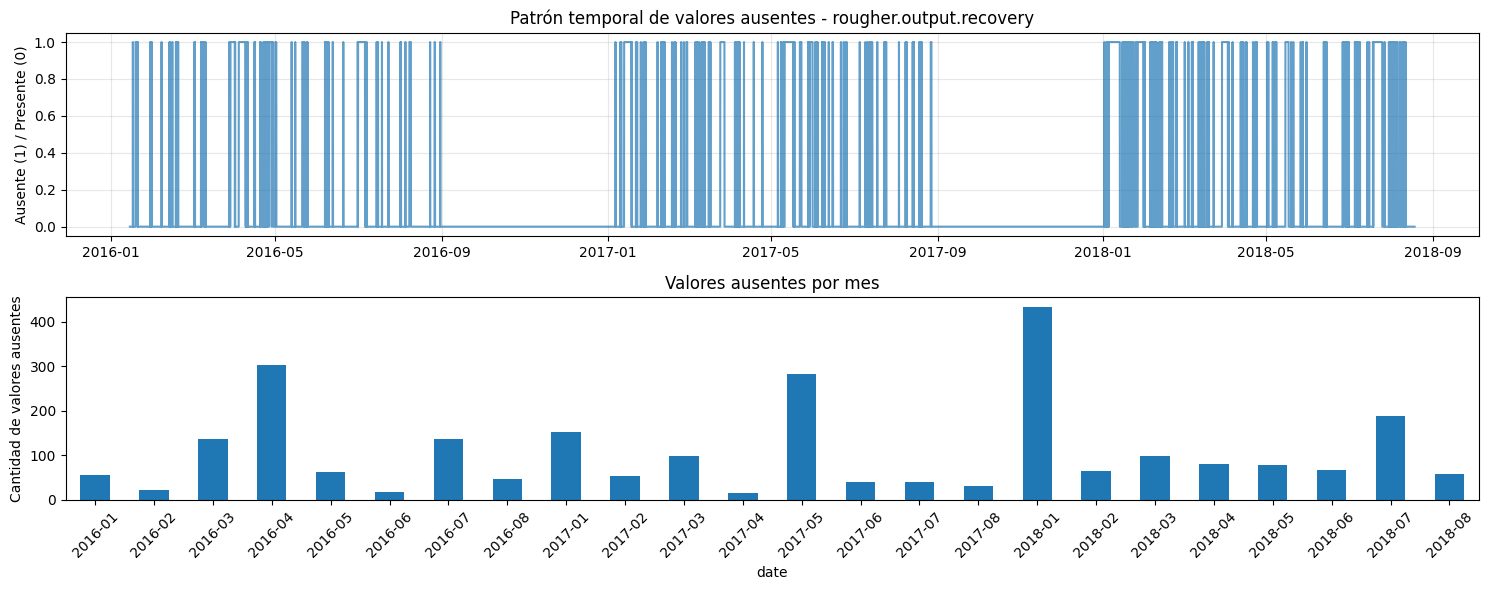

In [10]:
# Crear visualización para observar valores ausentes
# Convertir la columna date a datetime
gold_recovery_train['date'] = pd.to_datetime(gold_recovery_train['date'])

# Analizar patrones temporales de valores ausentes
column_to_analyze = 'rougher.output.recovery'  # 15.26% ausente

# Crear una serie que indique dónde hay valores ausentes
missing_pattern = gold_recovery_train[column_to_analyze].isnull()

print(f"Análisis de patrones para {column_to_analyze}:")
print(f"Total valores ausentes: {missing_pattern.sum()}")

# Crear una visualización temporal de valores ausentes
plt.figure(figsize=(15, 6))

# Crear una serie temporal que muestre valores ausentes (1) y presentes (0)
missing_timeline = gold_recovery_train[column_to_analyze].isnull().astype(int)

# Gráfico de línea temporal
plt.subplot(2, 1, 1)
plt.plot(gold_recovery_train['date'], missing_timeline, alpha=0.7)
plt.title(f'Patrón temporal de valores ausentes - {column_to_analyze}')
plt.ylabel('Ausente (1) / Presente (0)')
plt.grid(True, alpha=0.3)

# Histograma por mes para ver distribución
plt.subplot(2, 1, 2)
missing_by_month = gold_recovery_train[missing_pattern].groupby(gold_recovery_train['date'].dt.to_period('M')).size()
missing_by_month.plot(kind='bar')
plt.title('Valores ausentes por mes')
plt.ylabel('Cantidad de valores ausentes')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [11]:
# Analizar los períodos con más detalle
print("Análisis detallado de períodos con valores ausentes:")

# 1. Valores ausentes por día
missing_by_day = gold_recovery_train[missing_pattern].groupby(gold_recovery_train['date'].dt.date).size()
print(f"\nDías con más valores ausentes:")
print(missing_by_day.sort_values(ascending=False).head(10))

# 2. Valores ausentes por hora del día
missing_by_hour = gold_recovery_train[missing_pattern].groupby(gold_recovery_train['date'].dt.hour).size()
print(f"\nValores ausentes por hora del día:")
print(missing_by_hour)

# 3. Buscar secuencias consecutivas de valores ausentes
consecutive_missing = []
current_streak = 0
for is_missing in missing_pattern:
    if is_missing:
        current_streak += 1
    else:
        if current_streak > 0:
            consecutive_missing.append(current_streak)
        current_streak = 0

if consecutive_missing:
    print(f"\nSecuencias consecutivas de valores ausentes:")
    print(f"Secuencia más larga: {max(consecutive_missing)} horas")
    print(f"Promedio de secuencia: {sum(consecutive_missing)/len(consecutive_missing):.1f} horas")

Análisis detallado de períodos con valores ausentes:

Días con más valores ausentes:
date
2018-07-20    24
2016-04-08    24
2016-04-07    24
2016-04-05    24
2016-04-06    24
2016-03-31    24
2016-03-30    24
2018-01-27    24
2018-01-28    24
2018-01-29    24
dtype: int64

Valores ausentes por hora del día:
date
0      92
1      99
2     103
3     105
4     102
5     103
6     102
7      99
8     109
9     100
10    113
11    116
12    121
13    123
14    122
15    116
16    111
17    106
18    109
19    102
20    107
21    108
22    107
23     98
dtype: int64

Secuencias consecutivas de valores ausentes:
Secuencia más larga: 194 horas
Promedio de secuencia: 8.6 horas


De acuerdo con el análisis de esta variable, se observa que los datos se comportan en forma de patrones temporales, por lo que se opta por no eliminar filas con datos ausentes para no perder información valiosa de ciertos momentos del proceso y evitar afectar el análisis de tendencias y patrones. En vez de eliminar filas con valores ausentes, se optó por rellenar los valores ausentes usando una interpolación lineal pues la información del projecto menciona que los parámetros cercanos en el tiempo suelen ser similares.

In [15]:
# Implementar la imputación de datos usando la interpolación lineal

def impute_temporal_data(df, columns_to_impute):
    """
    Imputa valores ausentes usando interpolación temporal
    """
    df_imputed = df.copy()
    df_imputed = df_imputed.set_index('date')
    
    for column in columns_to_impute:
        # Interpolación lineal basada en tiempo
        df_imputed[column] = df_imputed[column].interpolate(method='time')
        
        # Para valores ausentes al inicio/final, usar forward/backward fill
        df_imputed[column] = df_imputed[column].ffill().bfill()
        #El método forward fill (ffill) toma el último valor válido disponible y lo "propaga hacia adelante" para rellenar los valores faltantes, se usa cuando el proceso industrial tiende a mantener condiciones estables hasta que hay un cambio
        #El método backward fill (bfill) toma el siguiente valor válido disponible y lo "propaga hacia atrás" para rellenar los valores faltantes, se usa cuando sabes que un valor futuro es representativo del período anterior
    return df_imputed

# Identificar columnas con valores ausentes
columns_with_missing = gold_recovery_train.columns[gold_recovery_train.isnull().any()].tolist()
#El método .any() devuelve True si al menos uno de los valores es True, devuelve False si todos son False
print(f"Columnas a imputar en el conjunto de entrenamiento: {len(columns_with_missing)}")

Columnas a imputar en el conjunto de entrenamiento: 85


In [16]:
#Rellenar valores ausentes usando la función impute_temporal_data en el conjunto de entrenamiento

gold_recovery_train_imputed = impute_temporal_data(gold_recovery_train, columns_with_missing)

In [17]:
# Identificar columnas con valores ausentes en el conjunto de prueba
columns_with_missing_test = gold_recovery_test.columns[gold_recovery_test.isnull().any()].tolist()
print(f"Columnas a imputar en el conjunto de prueba: {len(columns_with_missing_test)}")

#Rellenar valores ausentes usando la función impute_temporal_data en el conjunto de prueba
gold_recovery_test['date'] = pd.to_datetime(gold_recovery_test['date'])
gold_recovery_test_imputed = impute_temporal_data(gold_recovery_test, columns_with_missing_test)

Columnas a imputar en el conjunto de prueba: 51


In [18]:
# Identificar columnas con valores ausentes en el conjunto de datos completo
columns_with_missing_full = gold_recovery_full.columns[gold_recovery_full.isnull().any()].tolist()
print(f"Columnas a imputar en el conjunto completo: {len(columns_with_missing_test)}")

#Rellenar valores ausentes usando la función impute_temporal_data en el conjunto completo
gold_recovery_full['date'] = pd.to_datetime(gold_recovery_full['date'])
gold_recovery_full_imputed = impute_temporal_data(gold_recovery_full, columns_with_missing_full)


Columnas a imputar en el conjunto completo: 51


In [19]:
# Verificar que no quedan valores ausentes
print("Valores ausentes después de imputación:")
print(f"Train: {gold_recovery_train_imputed.isnull().sum().sum()}")
print(f"Test: {gold_recovery_test_imputed.isnull().sum().sum()}")

Valores ausentes después de imputación:
Train: 0
Test: 0


### Data Analysis (Análisis de datos)

#### 2.1. Observa cómo cambia la concentración de metales (Au, Ag, Pb) en función de la etapa de purificación¶

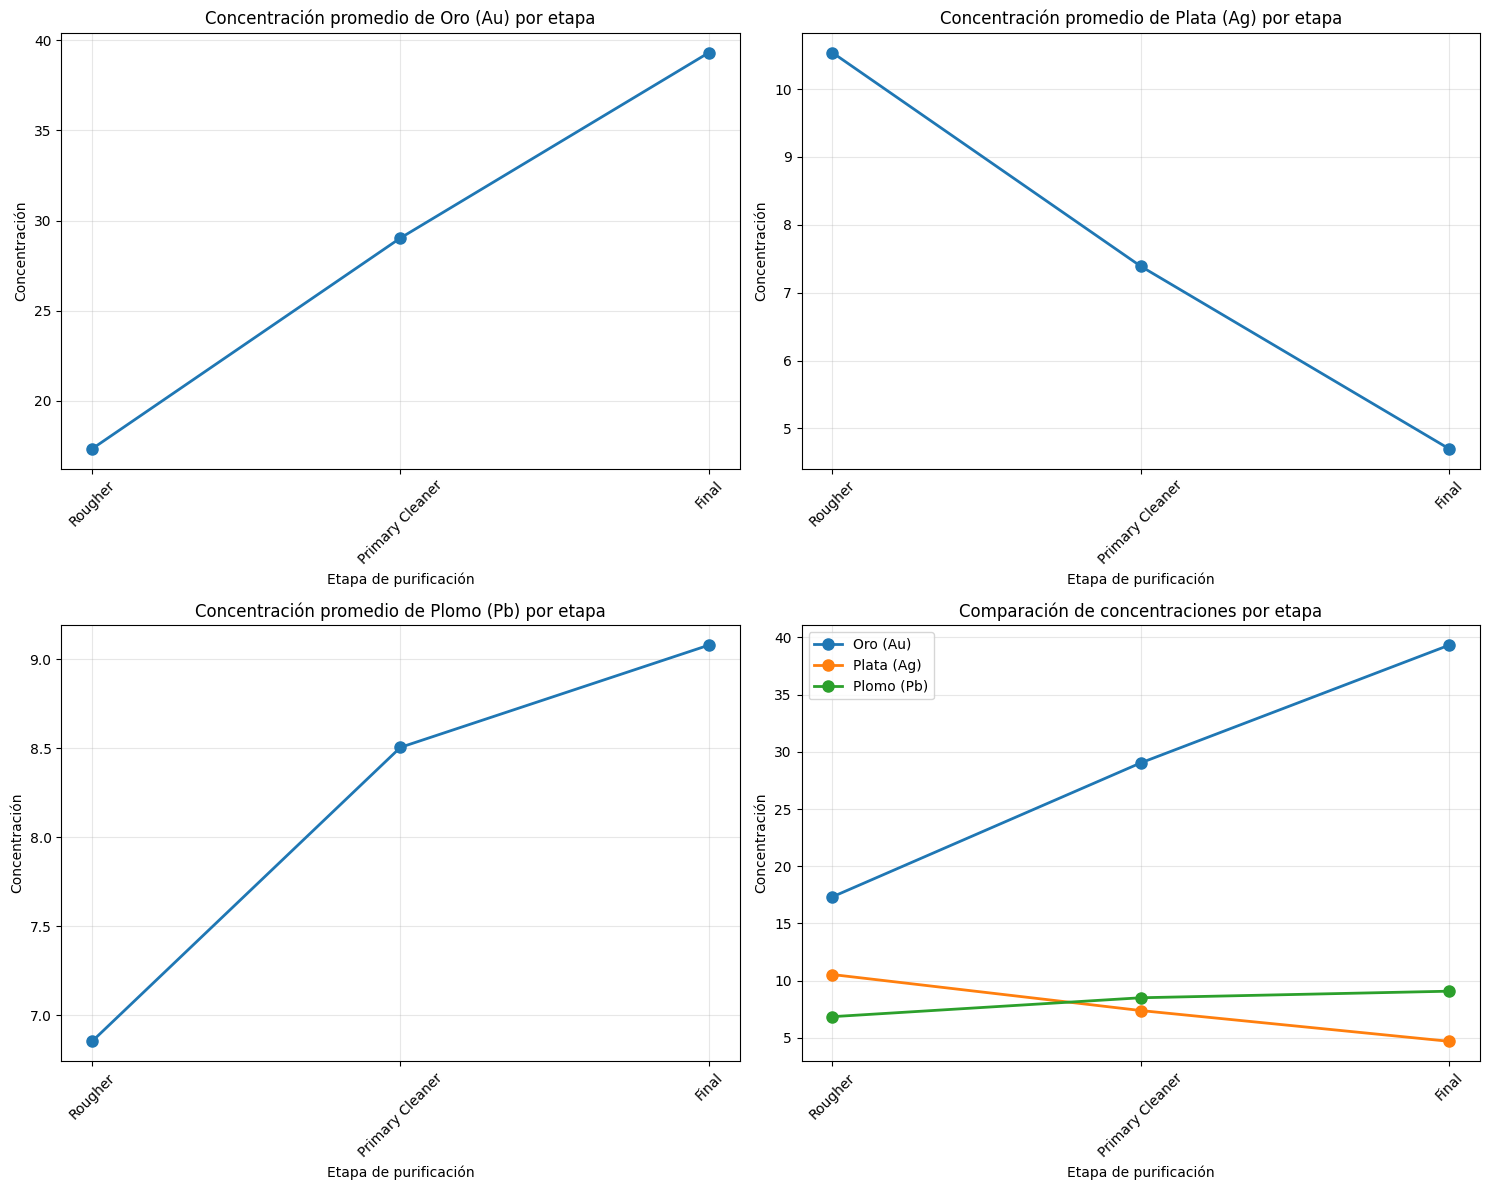

In [20]:
# Crear visualización de concentraciones de metales por etapa
plt.figure(figsize=(15, 12))

# Definir las etapas y metales
stages = ['rougher', 'primary_cleaner', 'secondary_cleaner', 'final']
metals = ['au', 'ag', 'pb']
metal_names = {'au': 'Oro (Au)', 'ag': 'Plata (Ag)', 'pb': 'Plomo (Pb)'}

# Crear subgráficos para cada metal
for i, metal in enumerate(metals):
    plt.subplot(2, 2, i+1)
    #.subplot() divide la "hoja" completa en secciones más pequeñas y pone un grafico diferente en cada sección
    
    concentrations = []
    stage_labels = []
    
    for stage in stages:
        # Buscar columnas de concentrado para cada etapa
        concentrate_col = f'{stage}.output.concentrate_{metal}'
        if concentrate_col in gold_recovery_train_imputed.columns:
            concentrations.append(gold_recovery_train_imputed[concentrate_col].mean())
            stage_labels.append(stage.replace('_', ' ').title())
    
    # Crear gráfico de línea
    plt.plot(stage_labels, concentrations, marker='o', linewidth=2, markersize=8)
    plt.title(f'Concentración promedio de {metal_names[metal]} por etapa')
    plt.xlabel('Etapa de purificación')
    plt.ylabel('Concentración')
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)

# Gráfico combinado
plt.subplot(2, 2, 4)
for metal in metals:
    concentrations = []
    stage_labels = []
    
    for stage in stages:
        concentrate_col = f'{stage}.output.concentrate_{metal}'
        if concentrate_col in gold_recovery_train_imputed.columns:
            concentrations.append(gold_recovery_train_imputed[concentrate_col].mean())
            stage_labels.append(stage.replace('_', ' ').title())
    
    plt.plot(stage_labels, concentrations, marker='o', linewidth=2, 
             markersize=8, label=metal_names[metal])

plt.title('Comparación de concentraciones por etapa')
plt.xlabel('Etapa de purificación')
plt.ylabel('Concentración')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

De acuerdo con los gráficos, se observa que la concentración de oro aumenta en cada una de las etapas del proceso, lo cual es lógico y es lo esperado, mientras que la plata disminuye conforme pasan las etapas, es decir, la relación de concentración entre el oro y la plata son inversamente proporcionales.

Por otro lado, se observa que las concentraciones de plomo aumentan de forma no considerable en comparación de la concentración de oro, este último metal supera por el doble la concentración del plomo en la etapa final del proceso.

#### 2.2. Compara las distribuciones del tamaño de las partículas de la alimentación en el conjunto de entrenamiento y en el conjunto de prueba. Si las distribuciones varían significativamente, la evaluación del modelo no será correcta

In [21]:
# Buscar las columnas objetivo en el conjunto de prueba

feed_size_cols_test = [col for col in gold_recovery_test.columns if 'feed' in col and 'size' in col]
print('Columnas disponibles en el conjunto de prueba:')
for col in feed_size_cols_test:
    print(f" - {col}")

Columnas disponibles en el conjunto de prueba:
 - primary_cleaner.input.feed_size
 - rougher.input.feed_size


In [22]:
# Buscar las columnas objetivo en el conjunto de entrenamiento

feed_size_cols_train = [col for col in gold_recovery_train.columns if 'feed' in col and 'size' in col]
print('Columnas disponibles en el conjunto de entrenamiento:')
for col in feed_size_cols_train:
    print(f" - {col}")

Columnas disponibles en el conjunto de entrenamiento:
 - primary_cleaner.input.feed_size
 - rougher.input.feed_size


In [23]:
# Comparar estadísticas descriptivas
print("ROUGHER FEED SIZE")
print("Entrenamiento:")
print(gold_recovery_train_imputed['rougher.input.feed_size'].describe())
print("\nPrueba:")
print(gold_recovery_test_imputed['rougher.input.feed_size'].describe())

print("\nPRIMARY CLEANER FEED SIZE")
print("Entrenamiento:")
print(gold_recovery_train_imputed['primary_cleaner.input.feed_size'].describe())
print("\nPrueba:")
print(gold_recovery_test_imputed['primary_cleaner.input.feed_size'].describe())

ROUGHER FEED SIZE
Entrenamiento:
count    16860.000000
mean        59.152776
std         26.131277
min          9.659576
25%         47.540138
50%         54.029671
75%         65.272775
max        484.967466
Name: rougher.input.feed_size, dtype: float64

Prueba:
count    5856.000000
mean       55.886800
std        22.704970
min         0.046369
25%        43.865121
50%        49.964796
75%        61.615634
max       477.445473
Name: rougher.input.feed_size, dtype: float64

PRIMARY CLEANER FEED SIZE
Entrenamiento:
count    16860.000000
mean         7.297285
std          0.619166
min          1.080000
25%          6.940000
50%          7.285000
75%          7.700000
max         10.470000
Name: primary_cleaner.input.feed_size, dtype: float64

Prueba:
count    5856.000000
mean        7.264651
std         0.611526
min         5.650000
25%         6.885625
50%         7.259333
75%         7.650000
max        15.500000
Name: primary_cleaner.input.feed_size, dtype: float64
